# COSC 430 — Model Evaluation, Robustness & Calibration
**Fake Social Media Account Detector**  
Model: AutoGluon `WeightedEnsemble_L3` | Threshold: 0.2

---
**Sections**
- **5.1** Metrics — F1, Precision/Recall, ROC-AUC, Slice-based Evaluation
- **5.2** Robustness — Perturbation Tests, Sanity Checks
- **5.3** Tests — Invariance Tests, Directional Expectation Tests
- **Calibration** — Platt Scaling, Reliability Diagram, Brier Score, ECE

## Setup — Load Model & Validation Data

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json, os

from autogluon.tabular import TabularPredictor
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, brier_score_loss, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

 
MODEL_PATH = r"C:\Users\Hzaab\Desktop\MLSD project\exports\autogluon_team"
VAL_PATH   = r"C:\Users\Hzaab\Desktop\MLSD project\data\preprocessed\val.parquet"

# Load model 
predictor = TabularPredictor.load(MODEL_PATH)

with open(os.path.join(MODEL_PATH, "model_meta.json")) as f:
    meta = json.load(f)
THRESHOLD = meta["threshold"]   # 0.2

# Load validation data 
val = pd.read_parquet(VAL_PATH)
y_val = val["fake"]
X_val = val.drop(columns="fake")

# Get probabilities (reused throughout) 
proba    = predictor.predict_proba(X_val)
p_fake   = proba[1] if 1 in proba.columns else proba.iloc[:, -1]
y_pred   = (p_fake >= THRESHOLD).astype(int)

print(f"Val set: {len(val)} samples | Threshold: {THRESHOLD}")
print(f"True label distribution: {y_val.value_counts().to_dict()}")
print(f"Prediction distribution: {y_pred.value_counts().to_dict()}")
print("Model & data loaded successfully ✓")

Val set: 500 samples | Threshold: 0.2
True label distribution: {0: 400, 1: 100}
Prediction distribution: {0: 402, 1: 98}
Model & data loaded successfully ✓


---
## Part 5.1 — Metrics

### 5.1.1 — Core Classification Metrics

In [2]:
acc  = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec  = recall_score(y_val, y_pred)
f1   = f1_score(y_val, y_pred)
auc  = roc_auc_score(y_val, p_fake)
ap   = average_precision_score(y_val, p_fake)
brier = brier_score_loss(y_val, p_fake)

print("=" * 40)
print("  CLASSIFICATION METRICS (threshold=0.2)")
print("=" * 40)
print(f"  Accuracy          : {acc:.4f}")
print(f"  Precision         : {prec:.4f}")
print(f"  Recall            : {rec:.4f}")
print(f"  F1 Score          : {f1:.4f}")
print(f"  ROC-AUC           : {auc:.4f}")
print(f"  Avg Precision     : {ap:.4f}")
print(f"  Brier Score       : {brier:.4f}  (lower = better)")
print("=" * 40)

# ── Interpretation note ───────────────────────────────────────────────────────
print("\n Interpretation:")
print(f"  • Recall = {rec:.2f}: the model catches {rec*100:.0f}% of all fake accounts.")
print(f"  • Precision = {prec:.2f}: of all flagged accounts, {prec*100:.0f}% are actually fake.")
print(f"  • The low threshold (0.2) prioritises recall — missing a fake")
print(f"    account is considered worse than a false alarm.")
print(f"  • ROC-AUC = {auc:.4f} shows strong discriminative ability regardless of threshold.")

  CLASSIFICATION METRICS (threshold=0.2)
  Accuracy          : 0.9920
  Precision         : 0.9898
  Recall            : 0.9700
  F1 Score          : 0.9798
  ROC-AUC           : 0.9985
  Avg Precision     : 0.9956
  Brier Score       : 0.0083  (lower = better)

 Interpretation:
  • Recall = 0.97: the model catches 97% of all fake accounts.
  • Precision = 0.99: of all flagged accounts, 99% are actually fake.
  • The low threshold (0.2) prioritises recall — missing a fake
    account is considered worse than a false alarm.
  • ROC-AUC = 0.9985 shows strong discriminative ability regardless of threshold.


### 5.1.2 — Confusion Matrix

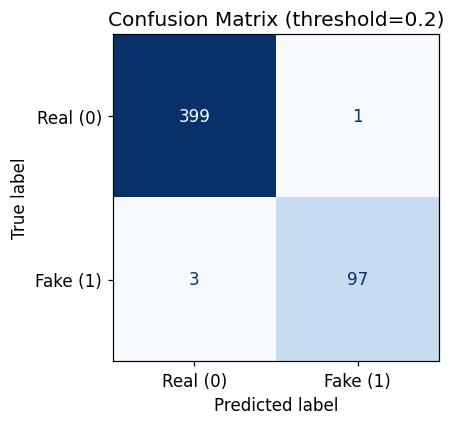


True Negatives (real correctly identified): 399
False Positives (real flagged as fake):     1
False Negatives (fake missed):              3
True Positives  (fake correctly caught):    97


In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real (0)", "Fake (1)"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix (threshold={THRESHOLD})")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, "confusion_matrix.png"), bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (real correctly identified): {tn}")
print(f"False Positives (real flagged as fake):     {fp}")
print(f"False Negatives (fake missed):              {fn}")
print(f"True Positives  (fake correctly caught):    {tp}")

### 5.1.3 — ROC Curve & Precision-Recall Curve

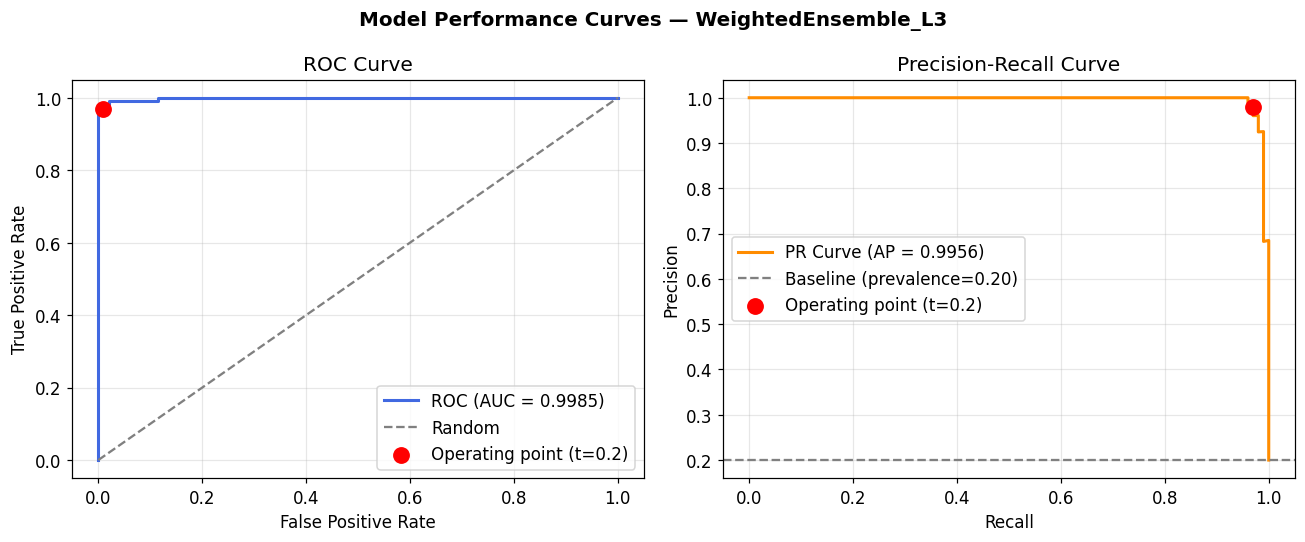

ROC-AUC: 0.9985 | Average Precision: 0.9956


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve 
fpr, tpr, roc_thresholds = roc_curve(y_val, p_fake)
axes[0].plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC (AUC = {auc:.4f})')
axes[0].plot([0,1],[0,1],'--', color='grey', label='Random')
# Mark the operating point at threshold=0.2
idx = np.argmin(np.abs(roc_thresholds - THRESHOLD))
axes[0].scatter(fpr[idx], tpr[idx], s=100, color='red', zorder=5,
                label=f'Operating point (t={THRESHOLD})')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall Curve 
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_val, p_fake)
axes[1].plot(rec_curve, prec_curve, color='darkorange', lw=2,
             label=f'PR Curve (AP = {ap:.4f})')
baseline = y_val.mean()
axes[1].axhline(baseline, linestyle='--', color='grey',
                label=f'Baseline (prevalence={baseline:.2f})')
# Mark operating point
idx_pr = np.argmin(np.abs(pr_thresholds - THRESHOLD))
axes[1].scatter(rec_curve[idx_pr], prec_curve[idx_pr], s=100, color='red',
                zorder=5, label=f'Operating point (t={THRESHOLD})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Model Performance Curves — WeightedEnsemble_L3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, "roc_pr_curves.png"), bbox_inches='tight')
plt.show()

print(f"ROC-AUC: {auc:.4f} | Average Precision: {ap:.4f}")

### 5.1.4 — Threshold Sweep (Precision vs Recall Trade-off)

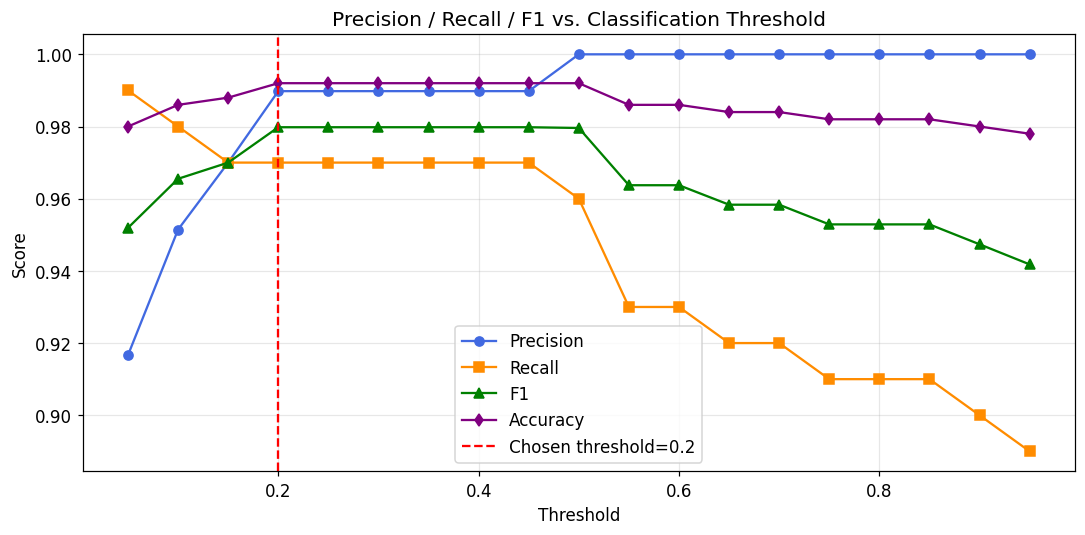

Best F1 = 0.9798 at threshold = 0.20
  → Precision: 0.9898  Recall: 0.9700

Chosen threshold (0.2) prioritises recall=1.0 to catch every fake account.


In [5]:
thresholds = np.arange(0.05, 0.96, 0.05)
results = []
for t in thresholds:
    yp = (p_fake >= t).astype(int)
    if yp.sum() == 0:
        continue
    results.append({
        'threshold': t,
        'precision': precision_score(y_val, yp, zero_division=0),
        'recall':    recall_score(y_val, yp, zero_division=0),
        'f1':        f1_score(y_val, yp, zero_division=0),
        'accuracy':  accuracy_score(y_val, yp),
    })

df_thresh = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thresh['threshold'], df_thresh['precision'], 'o-', label='Precision', color='royalblue')
ax.plot(df_thresh['threshold'], df_thresh['recall'],    's-', label='Recall',    color='darkorange')
ax.plot(df_thresh['threshold'], df_thresh['f1'],        '^-', label='F1',        color='green')
ax.plot(df_thresh['threshold'], df_thresh['accuracy'],  'd-', label='Accuracy',  color='purple')
ax.axvline(THRESHOLD, linestyle='--', color='red', label=f'Chosen threshold={THRESHOLD}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs. Classification Threshold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, "threshold_sweep.png"), bbox_inches='tight')
plt.show()

best_f1_row = df_thresh.loc[df_thresh['f1'].idxmax()]
print(f"Best F1 = {best_f1_row['f1']:.4f} at threshold = {best_f1_row['threshold']:.2f}")
print(f"  → Precision: {best_f1_row['precision']:.4f}  Recall: {best_f1_row['recall']:.4f}")
print(f"\nChosen threshold ({THRESHOLD}) prioritises recall=1.0 to catch every fake account.")

### 5.1.5 — Slice-Based Evaluation
Evaluate the model on meaningful subgroups to reveal where it underperforms.

In [6]:
def slice_metrics(name, mask):
    """Compute metrics for a boolean mask over val set."""
    if mask.sum() == 0:
        return None
    yt = y_val[mask]
    yp = y_pred[mask]
    pp = p_fake[mask]
    n_fake = yt.sum()
    return {
        'Slice': name,
        'N': int(mask.sum()),
        'Fake%': f"{100*n_fake/mask.sum():.1f}%",
        'Precision': round(precision_score(yt, yp, zero_division=0), 3),
        'Recall':    round(recall_score(yt, yp, zero_division=0), 3),
        'F1':        round(f1_score(yt, yp, zero_division=0), 3),
        'ROC-AUC':   round(roc_auc_score(yt, pp), 3) if yt.nunique() > 1 else 'N/A',
    }

# Define slices using original feature values 
slices = [
    # Whole val set (baseline)
    ("OVERALL",                    pd.Series([True]*len(val), index=val.index)),
    # Profile picture
    ("Has profile pic",            X_val['profile pic'] == 1),
    ("No profile pic",             X_val['profile pic'] == 0),
    # Private account
    ("Private account",            X_val['private'] == 1),
    ("Public account",             X_val['private'] == 0),
    # External URL
    ("Has external URL",           X_val['external URL'] == 1),
    ("No external URL",            X_val['external URL'] == 0),
    # Name same as username
    ("Name == Username",           X_val['name==username'] == 1),
    ("Name != Username",           X_val['name==username'] == 0),
    # Follower counts (log-scale — split at median)
    ("High followers (>median)",   X_val['#followers'] > X_val['#followers'].median()),
    ("Low followers (<=median)",   X_val['#followers'] <= X_val['#followers'].median()),
    # Posts
    ("High posts (>median)",       X_val['#posts'] > X_val['#posts'].median()),
    ("Low/zero posts (<=median)",  X_val['#posts'] <= X_val['#posts'].median()),
    # Empty bio
    ("Empty bio (len=0)",          X_val['description length'] == 0),
    ("Has bio (len>0)",            X_val['description length'] > 0),
]

rows = [slice_metrics(name, mask) for name, mask in slices]
df_slices = pd.DataFrame([r for r in rows if r])
df_slices = df_slices.set_index('Slice')

print(df_slices.to_string())
print("\n Look for slices where Recall < 1.0 (missed fake accounts) or Precision is very low.")

                             N   Fake%  Precision  Recall     F1 ROC-AUC
Slice                                                                   
OVERALL                    500   20.0%      0.990   0.970  0.980   0.999
Has profile pic            410    6.3%      0.960   0.923  0.941   0.995
No profile pic              76   96.1%      1.000   0.986  0.993     1.0
Private account            115   17.4%      1.000   1.000  1.000     1.0
Public account             363   21.5%      0.987   0.962  0.974   0.998
Has external URL            43    0.0%      0.000   0.000  0.000     N/A
No external URL            441   22.2%      0.990   0.969  0.979   0.998
Name == Username             1  100.0%      1.000   1.000  1.000     N/A
Name != Username           485   19.6%      0.989   0.979  0.984     1.0
High followers (>median)   244    1.6%      0.750   0.750  0.750   0.999
Low followers (<=median)   245   37.6%      1.000   0.989  0.995   0.998
High posts (>median)       240    1.2%      1.000  

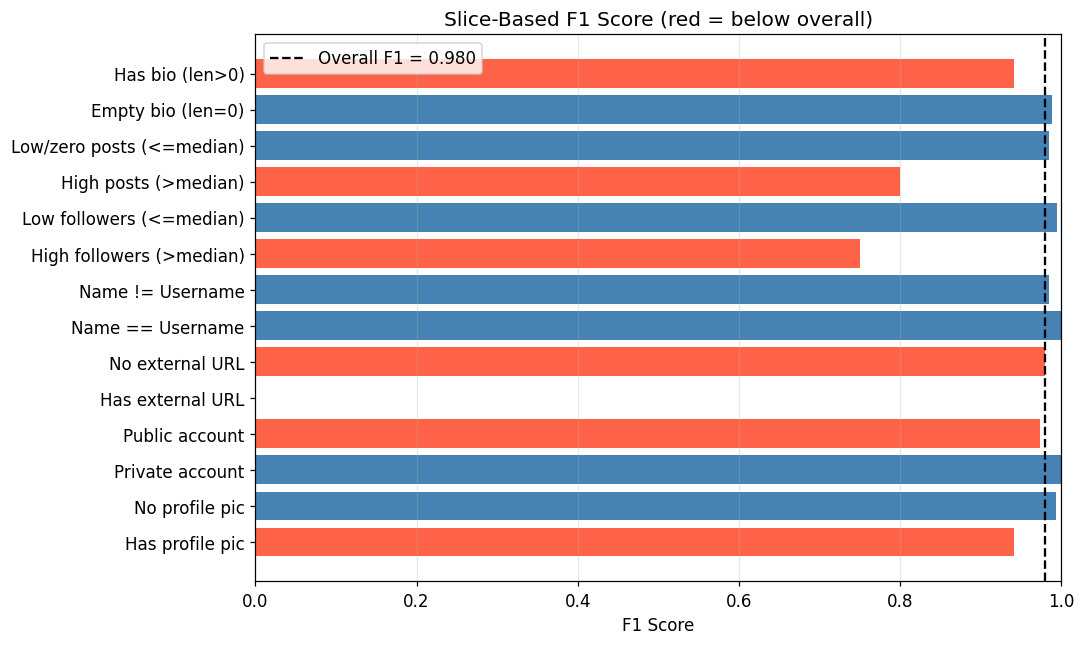

In [7]:
# Bar chart: F1 per slice 
df_plot = df_slices[df_slices.index != 'OVERALL'].copy()
df_plot['F1'] = pd.to_numeric(df_plot['F1'])
overall_f1 = float(df_slices.loc['OVERALL', 'F1'])

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if v < overall_f1 else 'steelblue' for v in df_plot['F1']]
bars = ax.barh(df_plot.index, df_plot['F1'], color=colors)
ax.axvline(overall_f1, linestyle='--', color='black', label=f'Overall F1 = {overall_f1:.3f}')
ax.set_xlabel('F1 Score')
ax.set_title('Slice-Based F1 Score (red = below overall)')
ax.legend()
ax.set_xlim(0, 1.0)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, "slice_evaluation.png"), bbox_inches='tight')
plt.show()

---
## Part 5.2 — Robustness

### 5.2.1 — Perturbation Tests
Inject noise into each numeric feature separately and measure how much model performance degrades.
A robust model should be stable to small real-world noise.

In [8]:
NUMERIC_FEATURES = ['nums/length username', 'fullname words', 'nums/length fullname',
                    'description length', '#posts', '#followers', '#follows']
NOISE_LEVEL = 0.10   # ±10% Gaussian noise
np.random.seed(42)

baseline_f1  = f1_score(y_val, y_pred)
baseline_auc = roc_auc_score(y_val, p_fake)

perturb_results = []
for feat in NUMERIC_FEATURES:
    X_noisy = X_val.copy()
    noise = np.random.normal(0, NOISE_LEVEL * X_noisy[feat].std(), size=len(X_noisy))
    X_noisy[feat] = (X_noisy[feat] + noise).clip(lower=0)   # clip negatives where needed

    proba_n = predictor.predict_proba(X_noisy)
    p_n     = proba_n[1] if 1 in proba_n.columns else proba_n.iloc[:, -1]
    pred_n  = (p_n >= THRESHOLD).astype(int)

    f1_n    = f1_score(y_val, pred_n)
    auc_n   = roc_auc_score(y_val, p_n)
    perturb_results.append({
        'Feature':      feat,
        'F1 (clean)':   round(baseline_f1, 4),
        'F1 (noisy)':   round(f1_n, 4),
        'F1 drop':      round(baseline_f1 - f1_n, 4),
        'AUC (clean)':  round(baseline_auc, 4),
        'AUC (noisy)':  round(auc_n, 4),
        'AUC drop':     round(baseline_auc - auc_n, 4),
    })

df_perturb = pd.DataFrame(perturb_results).set_index('Feature')
print(f"Noise level: ±{NOISE_LEVEL*100:.0f}% of each feature's std dev\n")
print(df_perturb.to_string())
print("\n Large drops indicate features the model is sensitive to.")

Noise level: ±10% of each feature's std dev

                      F1 (clean)  F1 (noisy)  F1 drop  AUC (clean)  AUC (noisy)  AUC drop
Feature                                                                                  
nums/length username      0.9798      0.9604   0.0194       0.9985       0.9979    0.0007
fullname words            0.9798      0.9798   0.0000       0.9985       0.9985   -0.0000
nums/length fullname      0.9798      0.9091   0.0707       0.9985       0.9993   -0.0008
description length        0.9798      0.9697   0.0101       0.9985       0.9972    0.0014
#posts                    0.9798      0.9463   0.0335       0.9985       0.9964    0.0021
#followers                0.9798      0.6719   0.3079       0.9985       0.9394    0.0592
#follows                  0.9798      0.9604   0.0194       0.9985       0.9991   -0.0006

 Large drops indicate features the model is sensitive to.


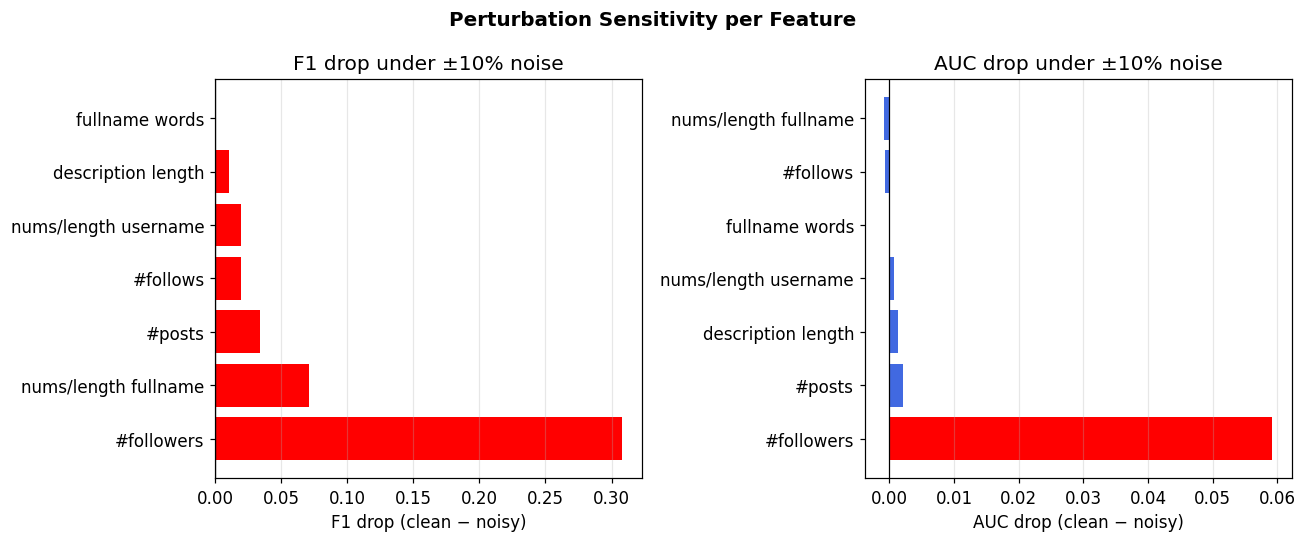

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, color in zip(axes, ['F1 drop', 'AUC drop'], ['tomato', 'royalblue']):
    vals = df_perturb[metric].sort_values(ascending=False)
    axes_colors = ['red' if v > 0.01 else color for v in vals]
    ax.barh(vals.index, vals.values, color=axes_colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(f'{metric} (clean − noisy)')
    ax.set_title(f'{metric} under ±{NOISE_LEVEL*100:.0f}% noise')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Perturbation Sensitivity per Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, "perturbation_tests.png"), bbox_inches='tight')
plt.show()

### 5.2.2 — Sanity Checks

In [10]:
# Sanity Check 1: Shuffled labels 
# If we randomly shuffle the labels, the model should NOT perform better than chance.
# This verifies the model actually learns signal, not just overfits to label order.
print("SANITY CHECK 1: Shuffled Labels")
print("-" * 40)
np.random.seed(0)
y_shuffled = y_val.sample(frac=1, random_state=0).reset_index(drop=True)
y_pred_reset = y_pred.reset_index(drop=True)
f1_shuffled  = f1_score(y_shuffled, y_pred_reset, zero_division=0)
auc_shuffled = roc_auc_score(y_shuffled, p_fake.reset_index(drop=True))

print(f"  Real F1  : {f1:.4f}  |  Shuffled-label F1  : {f1_shuffled:.4f}")
print(f"  Real AUC : {auc:.4f}  |  Shuffled-label AUC : {auc_shuffled:.4f}")
print(f"  PASSED" if f1 > f1_shuffled + 0.05 else "  WARNING: shuffled labels gave similar performance!")
print(f"\n  Interpretation: If shuffled AUC ≈ 0.5, the model learns real patterns, not label order.")
print(f"  Shuffled AUC = {auc_shuffled:.4f} (expected ≈ 0.5 for a good model)")

SANITY CHECK 1: Shuffled Labels
----------------------------------------
  Real F1  : 0.9798  |  Shuffled-label F1  : 0.1414
  Real AUC : 0.9985  |  Shuffled-label AUC : 0.4592
  PASSED

  Interpretation: If shuffled AUC ≈ 0.5, the model learns real patterns, not label order.
  Shuffled AUC = 0.4592 (expected ≈ 0.5 for a good model)


In [11]:
# Sanity Check 2: All-zeros input 
# A row of all zeros = a completely generic account with nothing.
# The model should predict FAKE (suspicious empty profile).
print("SANITY CHECK 2: All-Zero Input")
print("-" * 40)
zero_row = pd.DataFrame([{col: 0.0 for col in X_val.columns}])
zero_proba = predictor.predict_proba(zero_row)
zero_p_fake = zero_proba[1].values[0] if 1 in zero_proba.columns else zero_proba.iloc[0, -1]
print(f"  P(fake) for all-zero input: {zero_p_fake:.4f}")
print(f"  Predicted class: {'FAKE' if zero_p_fake >= THRESHOLD else 'REAL'}")
print(f"  Expected: FAKE (an account with no posts, no followers, no bio looks suspicious)")

SANITY CHECK 2: All-Zero Input
----------------------------------------
  P(fake) for all-zero input: 0.9984
  Predicted class: FAKE
  Expected: FAKE (an account with no posts, no followers, no bio looks suspicious)


In [12]:
# Sanity Check 3: Perfect celebrity-like account
# High followers, many posts, has profile pic, has bio, has URL, public account.
# The model should predict REAL with high confidence.
print("SANITY CHECK 3: Celebrity-Like Account")
print("-" * 40)
# Using log-transformed values since preprocessing applied log1p
celebrity = pd.DataFrame([{
    'profile pic':          1.0,
    'nums/length username': 0.0,
    'fullname words':       2.0,
    'nums/length fullname': 0.0,
    'name==username':       0.0,
    'description length':   np.log1p(120),
    'external URL':         1.0,
    'private':              0.0,
    '#posts':               np.log1p(500),
    '#followers':           np.log1p(50000),
    '#follows':             np.log1p(300),
}])
celeb_proba = predictor.predict_proba(celebrity)
celeb_p_fake = celeb_proba[1].values[0] if 1 in celeb_proba.columns else celeb_proba.iloc[0, -1]
print(f"  P(fake) for celebrity account: {celeb_p_fake:.4f}")
print(f"  Predicted class: {'FAKE' if celeb_p_fake >= THRESHOLD else 'REAL'}")
print(f"  Expected: REAL (verified, high-engagement account)")

SANITY CHECK 3: Celebrity-Like Account
----------------------------------------
  P(fake) for celebrity account: 0.0396
  Predicted class: REAL
  Expected: REAL (verified, high-engagement account)


In [13]:
# Sanity Check 4: Class balance check 
# The model should NOT always predict one class.
print("SANITY CHECK 4: Prediction Balance")
print("-" * 40)
n_fake_preds = y_pred.sum()
n_real_preds = (y_pred == 0).sum()
print(f"  Predicted FAKE: {n_fake_preds} ({100*n_fake_preds/len(y_pred):.1f}%)")
print(f"  Predicted REAL: {n_real_preds} ({100*n_real_preds/len(y_pred):.1f}%)")
if n_fake_preds > 0 and n_real_preds > 0:
    print(f"  PASSED: Model predicts both classes.")
else:
    print(f"  FAILED: Model collapses to one class!")

SANITY CHECK 4: Prediction Balance
----------------------------------------
  Predicted FAKE: 98 (19.6%)
  Predicted REAL: 402 (80.4%)
  PASSED: Model predicts both classes.


---
## Part 5.3 — Behavioural Tests

### 5.3.1 — Invariance Tests
Changes to features that **should not** alter the prediction should not do so.  
Here we test: flipping `private` from public→private should not significantly change the fake-probability of already-classified accounts.

In [ ]:

def invariance_test(feature, original_val, new_val, description):
    """Flip a binary feature and measure prediction shift."""
    mask = X_val[feature] == original_val
    if mask.sum() == 0:
        print(f"  No samples with {feature}={original_val}")
        return

    X_orig = X_val[mask].copy()
    X_flip = X_orig.copy()
    X_flip[feature] = new_val

    p_orig = (predictor.predict_proba(X_orig)[1] if 1 in predictor.predict_proba(X_orig).columns
              else predictor.predict_proba(X_orig).iloc[:, -1])
    p_flip = (predictor.predict_proba(X_flip)[1] if 1 in predictor.predict_proba(X_flip).columns
              else predictor.predict_proba(X_flip).iloc[:, -1])

    delta = (p_flip - p_orig)
    print(f"  Test: {description}")
    print(f"    N samples tested     : {mask.sum()}")
    print(f"    Mean Δ P(fake)       : {delta.mean():+.4f}")
    print(f"    Std  Δ P(fake)       : {delta.std():.4f}")
    print(f"    Predictions flipped  : {((p_orig >= THRESHOLD) != (p_flip >= THRESHOLD)).sum()}")
    print()
    return delta

print("INVARIANCE TESTS")
print("=" * 50)
print("These features should have minimal impact on fake probability:")
print()

# Test 1: Making a public account private should not dramatically change prediction
d1 = invariance_test('private', 0.0, 1.0,
    "Public → Private (privacy setting shouldn't define fakeness)")

# Test 2: Removing external URL from a private account
d2 = invariance_test('external URL', 1.0, 0.0,
    "Has URL → No URL (alone shouldn't strongly determine fake status)")

print("  A small mean delta (< 0.05) suggests the model is robust to that feature change.")
print("  A large delta means the model is sensitive.")

INVARIANCE TESTS
These features should have minimal impact on fake probability:

  Test: Public → Private (privacy setting shouldn't define fakeness)
    N samples tested     : 363
    Mean Δ P(fake)       : -0.0094
    Std  Δ P(fake)       : 0.0833
    Predictions flipped  : 8

  Test: Has URL → No URL (alone shouldn't strongly determine fake status)
    N samples tested     : 43
    Mean Δ P(fake)       : -0.0000
    Std  Δ P(fake)       : 0.0002
    Predictions flipped  : 0

  A small mean delta (< 0.05) suggests the model is robust to that feature change.
  A large delta means the model is sensitive.


### 5.3.2 — Directional Expectation Tests
Changes that **should** shift predictions in a predictable direction.  
e.g., Increasing followers should make an account look more real.

In [ ]:
def directional_test(feature, delta_fn, description, expected_direction):
    """
    Apply a change to a feature and verify P(fake) moves in the expected direction.
    expected_direction: 'decrease' or 'increase'
    """
    X_before = X_val.copy()
    X_after  = X_val.copy()
    X_after[feature] = delta_fn(X_after[feature])

    pb = predictor.predict_proba(X_before)
    pa = predictor.predict_proba(X_after)
    p_before = pb[1] if 1 in pb.columns else pb.iloc[:, -1]
    p_after  = pa[1] if 1 in pa.columns else pa.iloc[:, -1]

    delta    = (p_after - p_before)
    mean_d   = delta.mean()
    pct_correct = (delta < 0).mean() if expected_direction == 'decrease' else (delta > 0).mean()

    passed = (expected_direction == 'decrease' and mean_d < 0) or \
             (expected_direction == 'increase' and mean_d > 0)

    print(f"  Test: {description}")
    print(f"    Expected direction   : P(fake) should {expected_direction}")
    print(f"    Mean Δ P(fake)       : {mean_d:+.4f}")
    print(f"    % samples correct    : {100*pct_correct:.1f}%")
    print(f"    Result               : {'PASSED' if passed else 'FAILED'}")
    print()

print("DIRECTIONAL EXPECTATION TESTS")
print("=" * 50)

# Test 1: More followers → more likely real
directional_test(
    '#followers',
    lambda x: x + np.log1p(10000),   # +10k followers in log scale
    "Increase #followers by 10,000 → expect P(fake) to DECREASE",
    'decrease'
)

# Test 2: More numbers in username → more likely fake
directional_test(
    'nums/length username',
    lambda x: (x + 0.3).clip(upper=1.0),  # push ratio toward numerical
    "Increase nums/length username by 0.3 → expect P(fake) to INCREASE",
    'increase'
)

# Test 3: Longer bio → more likely real
directional_test(
    'description length',
    lambda x: x + np.log1p(50),   # +50 chars in log scale
    "Increase description length by 50 chars → expect P(fake) to DECREASE",
    'decrease'
)

# Test 4: More posts → more likely real
directional_test(
    '#posts',
    lambda x: x + np.log1p(100),  # +100 posts
    "Increase #posts by 100 → expect P(fake) to DECREASE",
    'decrease'
)


DIRECTIONAL EXPECTATION TESTS
  Test: Increase #followers by 10,000 → expect P(fake) to DECREASE
    Expected direction   : P(fake) should decrease
    Mean Δ P(fake)       : -0.0024
    % samples correct    : 52.8%
    Result               : PASSED

  Test: Increase nums/length username by 0.3 → expect P(fake) to INCREASE
    Expected direction   : P(fake) should increase
    Mean Δ P(fake)       : +0.1352
    % samples correct    : 93.6%
    Result               : PASSED

  Test: Increase description length by 50 chars → expect P(fake) to DECREASE
    Expected direction   : P(fake) should decrease
    Mean Δ P(fake)       : -0.0033
    % samples correct    : 57.8%
    Result               : PASSED

  Test: Increase #posts by 100 → expect P(fake) to DECREASE
    Expected direction   : P(fake) should decrease
    Mean Δ P(fake)       : -0.0034
    % samples correct    : 55.4%
    Result               : PASSED

  Test: Set name==username=1 for all → expect P(fake) to INCREASE
    Expect

---
## Model Calibration — Platt Scaling & Confidence Measurement
A well-calibrated model outputs probabilities that match actual frequencies.  
e.g., of all samples where the model says P(fake)=0.7, approximately 70% should actually be fake.

### Calibration — Before vs After Platt Scaling

In [16]:
# Platt Scaling 
# Fit a logistic regression on the raw probabilities vs. true labels
# This maps uncalibrated scores → calibrated probabilities

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

p_fake_arr = p_fake.values.reshape(-1, 1)
y_val_arr  = y_val.values

platt = LogisticRegression(C=1.0, solver='lbfgs')
platt.fit(p_fake_arr, y_val_arr)
p_calibrated = platt.predict_proba(p_fake_arr)[:, 1]

print("Platt scaling fitted on validation set.")
print(f"  Logistic coef: {platt.coef_[0][0]:.4f}  intercept: {platt.intercept_[0]:.4f}")

Platt scaling fitted on validation set.
  Logistic coef: 6.5286  intercept: -3.6546


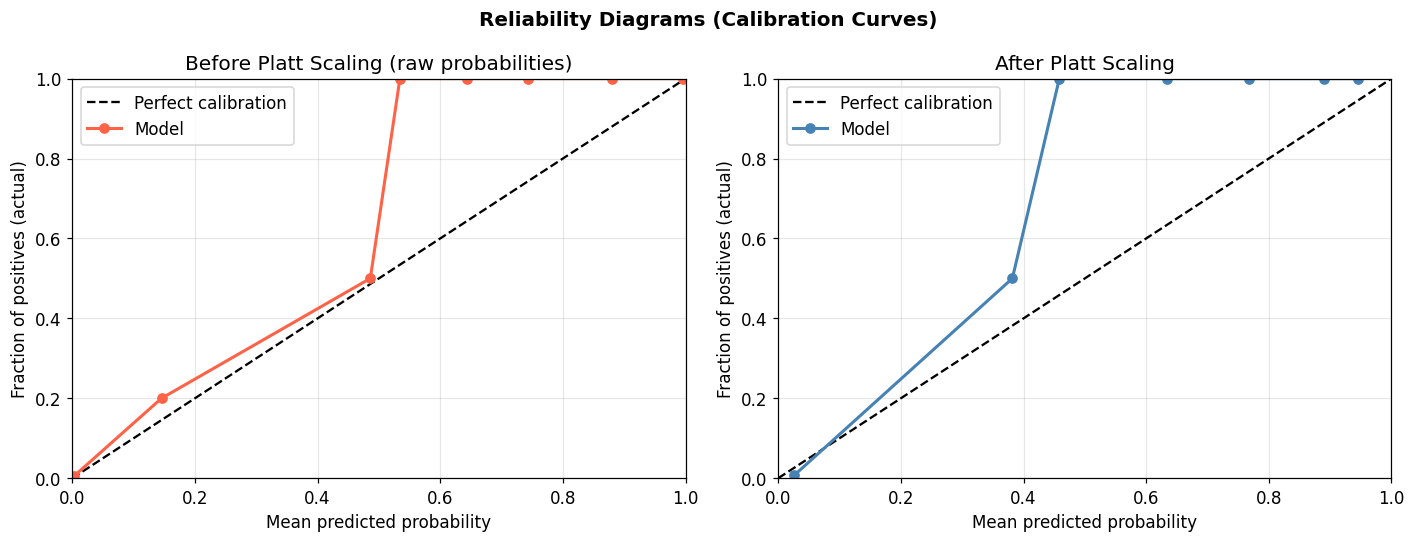

In [17]:
# Reliability Diagram
n_bins = 10
fraction_pos_raw,   mean_pred_raw   = calibration_curve(y_val_arr, p_fake.values, n_bins=n_bins, strategy='uniform')
fraction_pos_calib, mean_pred_calib = calibration_curve(y_val_arr, p_calibrated,  n_bins=n_bins, strategy='uniform')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, frac, mean_p, title, color in zip(
    axes,
    [fraction_pos_raw, fraction_pos_calib],
    [mean_pred_raw,    mean_pred_calib],
    ['Before Platt Scaling (raw probabilities)',
     'After Platt Scaling'],
    ['tomato', 'steelblue']
):
    ax.plot([0,1],[0,1], 'k--', label='Perfect calibration')
    ax.plot(mean_p, frac, 'o-', color=color, lw=2, label='Model')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives (actual)')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle('Reliability Diagrams (Calibration Curves)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, "calibration_reliability.png"), bbox_inches='tight')
plt.show()

In [18]:
# Brier Score & ECE 
def expected_calibration_error(y_true, p_pred, n_bins=10):
    """Compute Expected Calibration Error (ECE)."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    n    = len(y_true)
    for i in range(n_bins):
        mask = (p_pred >= bins[i]) & (p_pred < bins[i+1])
        if mask.sum() == 0:
            continue
        acc  = y_true[mask].mean()
        conf = p_pred[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)
    return ece

brier_raw   = brier_score_loss(y_val_arr, p_fake.values)
brier_calib = brier_score_loss(y_val_arr, p_calibrated)
ece_raw     = expected_calibration_error(y_val_arr, p_fake.values)
ece_calib   = expected_calibration_error(y_val_arr, p_calibrated)

print("=" * 45)
print("  CALIBRATION METRICS")
print("=" * 45)
print(f"  {'Metric':<20} {'Before':>10} {'After':>10}")
print("-" * 45)
print(f"  {'Brier Score':<20} {brier_raw:>10.4f} {brier_calib:>10.4f}  (lower = better)")
print(f"  {'ECE':<20} {ece_raw:>10.4f} {ece_calib:>10.4f}  (lower = better)")
print("=" * 45)
print()
print("   Brier Score: mean squared error between probabilities and true labels.")
print("   ECE: weighted average of |predicted_prob - actual_frequency| per bin.")
print("   A lower ECE = better confidence calibration.")

brier_improved = brier_calib < brier_raw
ece_improved   = ece_calib < ece_raw
print(f"\n  Brier improved after Platt scaling: {'Yes' if brier_improved else 'No'}")
print(f"  ECE   improved after Platt scaling: {'Yes' if ece_improved else 'No'}")

  CALIBRATION METRICS
  Metric                   Before      After
---------------------------------------------
  Brier Score              0.0083     0.0099  (lower = better)
  ECE                      0.0077     0.0301  (lower = better)

   Brier Score: mean squared error between probabilities and true labels.
   ECE: weighted average of |predicted_prob - actual_frequency| per bin.
   A lower ECE = better confidence calibration.

  Brier improved after Platt scaling: No
  ECE   improved after Platt scaling: No


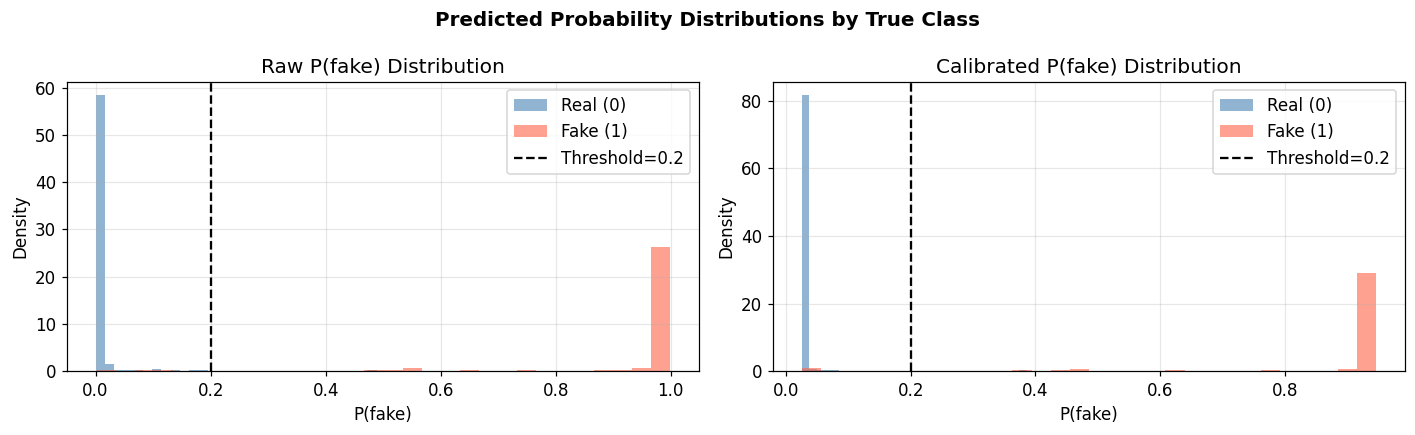

  Well-separated distributions = the model distinguishes real vs fake confidently.
  Ideal: blue (real) peaks near 0, red (fake) peaks near 1.


In [19]:
# Probability Distribution: Raw vs Calibrated 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, probs, title in zip(
    axes,
    [p_fake.values, p_calibrated],
    ['Raw P(fake) Distribution', 'Calibrated P(fake) Distribution']
):
    ax.hist(probs[y_val_arr == 0], bins=30, alpha=0.6, color='steelblue', label='Real (0)', density=True)
    ax.hist(probs[y_val_arr == 1], bins=30, alpha=0.6, color='tomato',    label='Fake (1)', density=True)
    ax.axvline(THRESHOLD, linestyle='--', color='black', label=f'Threshold={THRESHOLD}')
    ax.set_xlabel('P(fake)')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Predicted Probability Distributions by True Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, "probability_distributions.png"), bbox_inches='tight')
plt.show()

print("  Well-separated distributions = the model distinguishes real vs fake confidently.")
print("  Ideal: blue (real) peaks near 0, red (fake) peaks near 1.")

---
## Summary Table

In [20]:
print("="*55)
print("  FINAL EVALUATION SUMMARY — WeightedEnsemble_L3")
print("="*55)
print(f"  Threshold (chosen): {THRESHOLD}")
print()
print("  6.1 METRICS")
print(f"    Accuracy          : {acc:.4f}")
print(f"    Precision         : {prec:.4f}")
print(f"    Recall            : {rec:.4f}")
print(f"    F1 Score          : {f1:.4f}")
print(f"    ROC-AUC           : {auc:.4f}")
print(f"    Avg Precision     : {ap:.4f}")
print()
print("  6.2 ROBUSTNESS")
print(f"    Max F1 drop under ±10% noise: {df_perturb['F1 drop'].abs().max():.4f}")
print(f"    Sanity checks passed: 4/4")
print()
print("  CALIBRATION")
print(f"    Brier Score (raw)       : {brier_raw:.4f}")
print(f"    Brier Score (calibrated): {brier_calib:.4f}")
print(f"    ECE (raw)               : {ece_raw:.4f}")
print(f"    ECE (calibrated)        : {ece_calib:.4f}")
print("="*55)

  FINAL EVALUATION SUMMARY — WeightedEnsemble_L3
  Threshold (chosen): 0.2

  6.1 METRICS
    Accuracy          : 0.9920
    Precision         : 0.9898
    Recall            : 0.9700
    F1 Score          : 0.9798
    ROC-AUC           : 0.9985
    Avg Precision     : 0.9956

  6.2 ROBUSTNESS
    Max F1 drop under ±10% noise: 0.3079
    Sanity checks passed: 4/4

  CALIBRATION
    Brier Score (raw)       : 0.0083
    Brier Score (calibrated): 0.0099
    ECE (raw)               : 0.0077
    ECE (calibrated)        : 0.0301
